In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib import colors
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats
import illustris_python as il
from astropy import units as u
from match_with_crash import get_crash_df_with_semi
from plotting_routines import *
from get_scale_height import *
from utils import *
import h5py

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
h = 0.6774

In [5]:
from calculate_gridded_fesc import *

In [6]:
from plotting_routines import *

In [7]:
df_name="full_df.pickle"
base_path="/ptmp/mpa/ivkos/semianalytic_fesc"
snap_num = 13
sim, sim_path = get_sim()
z = get_redshift(sim, snap_num)
snap = get_snap(snap_num)
origin_path = os.path.join(base_path, snap, df_name)
df = pd.read_pickle(origin_path)

In [7]:
df_name="full_height_df.pickle"
base_path="/ptmp/mpa/ivkos/semianalytic_fesc"
snap_num = 13
sim, sim_path = get_sim()
z = get_redshift(sim, snap_num)
snap = get_snap(snap_num)
origin_path = os.path.join(base_path, snap, df_name)
# df_height = pd.read_pickle(origin_path)

In [91]:
mass_to_g = (1 * u.Msun).to(u.g).value * 1e10 / h

In [8]:
_, weights = select_sample_df(df, sample_size=100, with_weights=True)

In [34]:
test_path = os.path.join(base_path, snap, 'test_df_ad.pickle')
test_path2 = os.path.join(base_path, snap, 'test_df2_updated.pickle')

In [35]:
test_df = pd.read_pickle(test_path)

In [62]:
test_df2 = pd.read_pickle(test_path2)

In [56]:
f2.keys()

<KeysViewHDF5 ['0.3', '0.35', '0.4', '0.45', '0.5', '0.55', '0.6', '0.65', '0.7', '0.75', '0.8', '0.85', '0.9', '0.95', '1.0', '1.05', '1.1', '1.15', '1.2', '1.25', '1.3', '1.35', '1.4', '1.45', '1.5', '1.55', '1.6', '1.65', '1.7', '1.75', '1.8', '1.85', '1.9', '1.95', '2.0']>

In [121]:
overlap = []
for key in f2['1.0'].keys():
    if key in f['1.0']:
        overlap.append(key)

In [86]:
f['1.0'].keys()

<KeysViewHDF5 ['0', '100127', '110018', '115015', '12163', '133421', '13343', '134734', '138844', '13898', '14103', '142458', '1445', '15004', '153193', '154161', '160776', '16904', '17164', '172486', '180333', '182590', '18405', '184078', '18933', '19416', '195825', '200698', '202154', '206919', '219676', '221746', '240132', '25836', '2668', '2877', '30223', '305088', '31615', '32346', '339058', '3401', '371795', '372960', '379332', '38791', '3946', '40801', '423112', '4308', '443916', '4485', '472320', '48064', '5289', '53635', '541302', '5531', '575871', '597479', '6191', '642', '643', '669', '6956', '69750', '7151', '71795', '7251', '73221', '7367', '74496', '81874', '8635', '91915', '92294', '9345', '9550', '9740', '99548']>

In [127]:
idx = 2877

In [128]:
test_df.loc[idx, 'Grid_cell_size_1.5']

2.372321318545626e+20

In [130]:
test_df2.loc[idx, 'Grid_cell_size_0.35']

2.2827997593731098e+20

In [126]:
for idx in overlap[:-1]:
    for key in f.keys():
        if test_df.loc[int(idx), f'f_esc_{key}'] > 0.01:
            print(idx)
            print(key)
            print(test_df.loc[int(idx), f'f_esc_{key}'])

2877
1.5
0.013784192388859015


In [132]:
test_df.loc[idx, 'f_esc_1.5']

0.013784192388859015

In [131]:
test_df2.loc[idx, 'f_esc_0.35']

0.01406455447795882

In [12]:
hdf_path = '/ptmp/mpa/ivkos/semianalytic_fesc/sn013/maps_adaptive_full.hdf5'
f = h5py.File(hdf_path, 'a')

In [55]:
hdf_path2 = '/ptmp/mpa/ivkos/semianalytic_fesc/sn013/maps2.hdf5'
f2 = h5py.File(hdf_path2, 'a')

In [13]:
scales = np.array(list(f.keys())).astype('float')

In [15]:
scale_names = f.keys()

In [16]:
weights = list(weights)

In [17]:
weights = np.array(weights)

In [80]:
maps2 = f2['0.35']['5531']

In [22]:
maps = f['0.5']['25836']

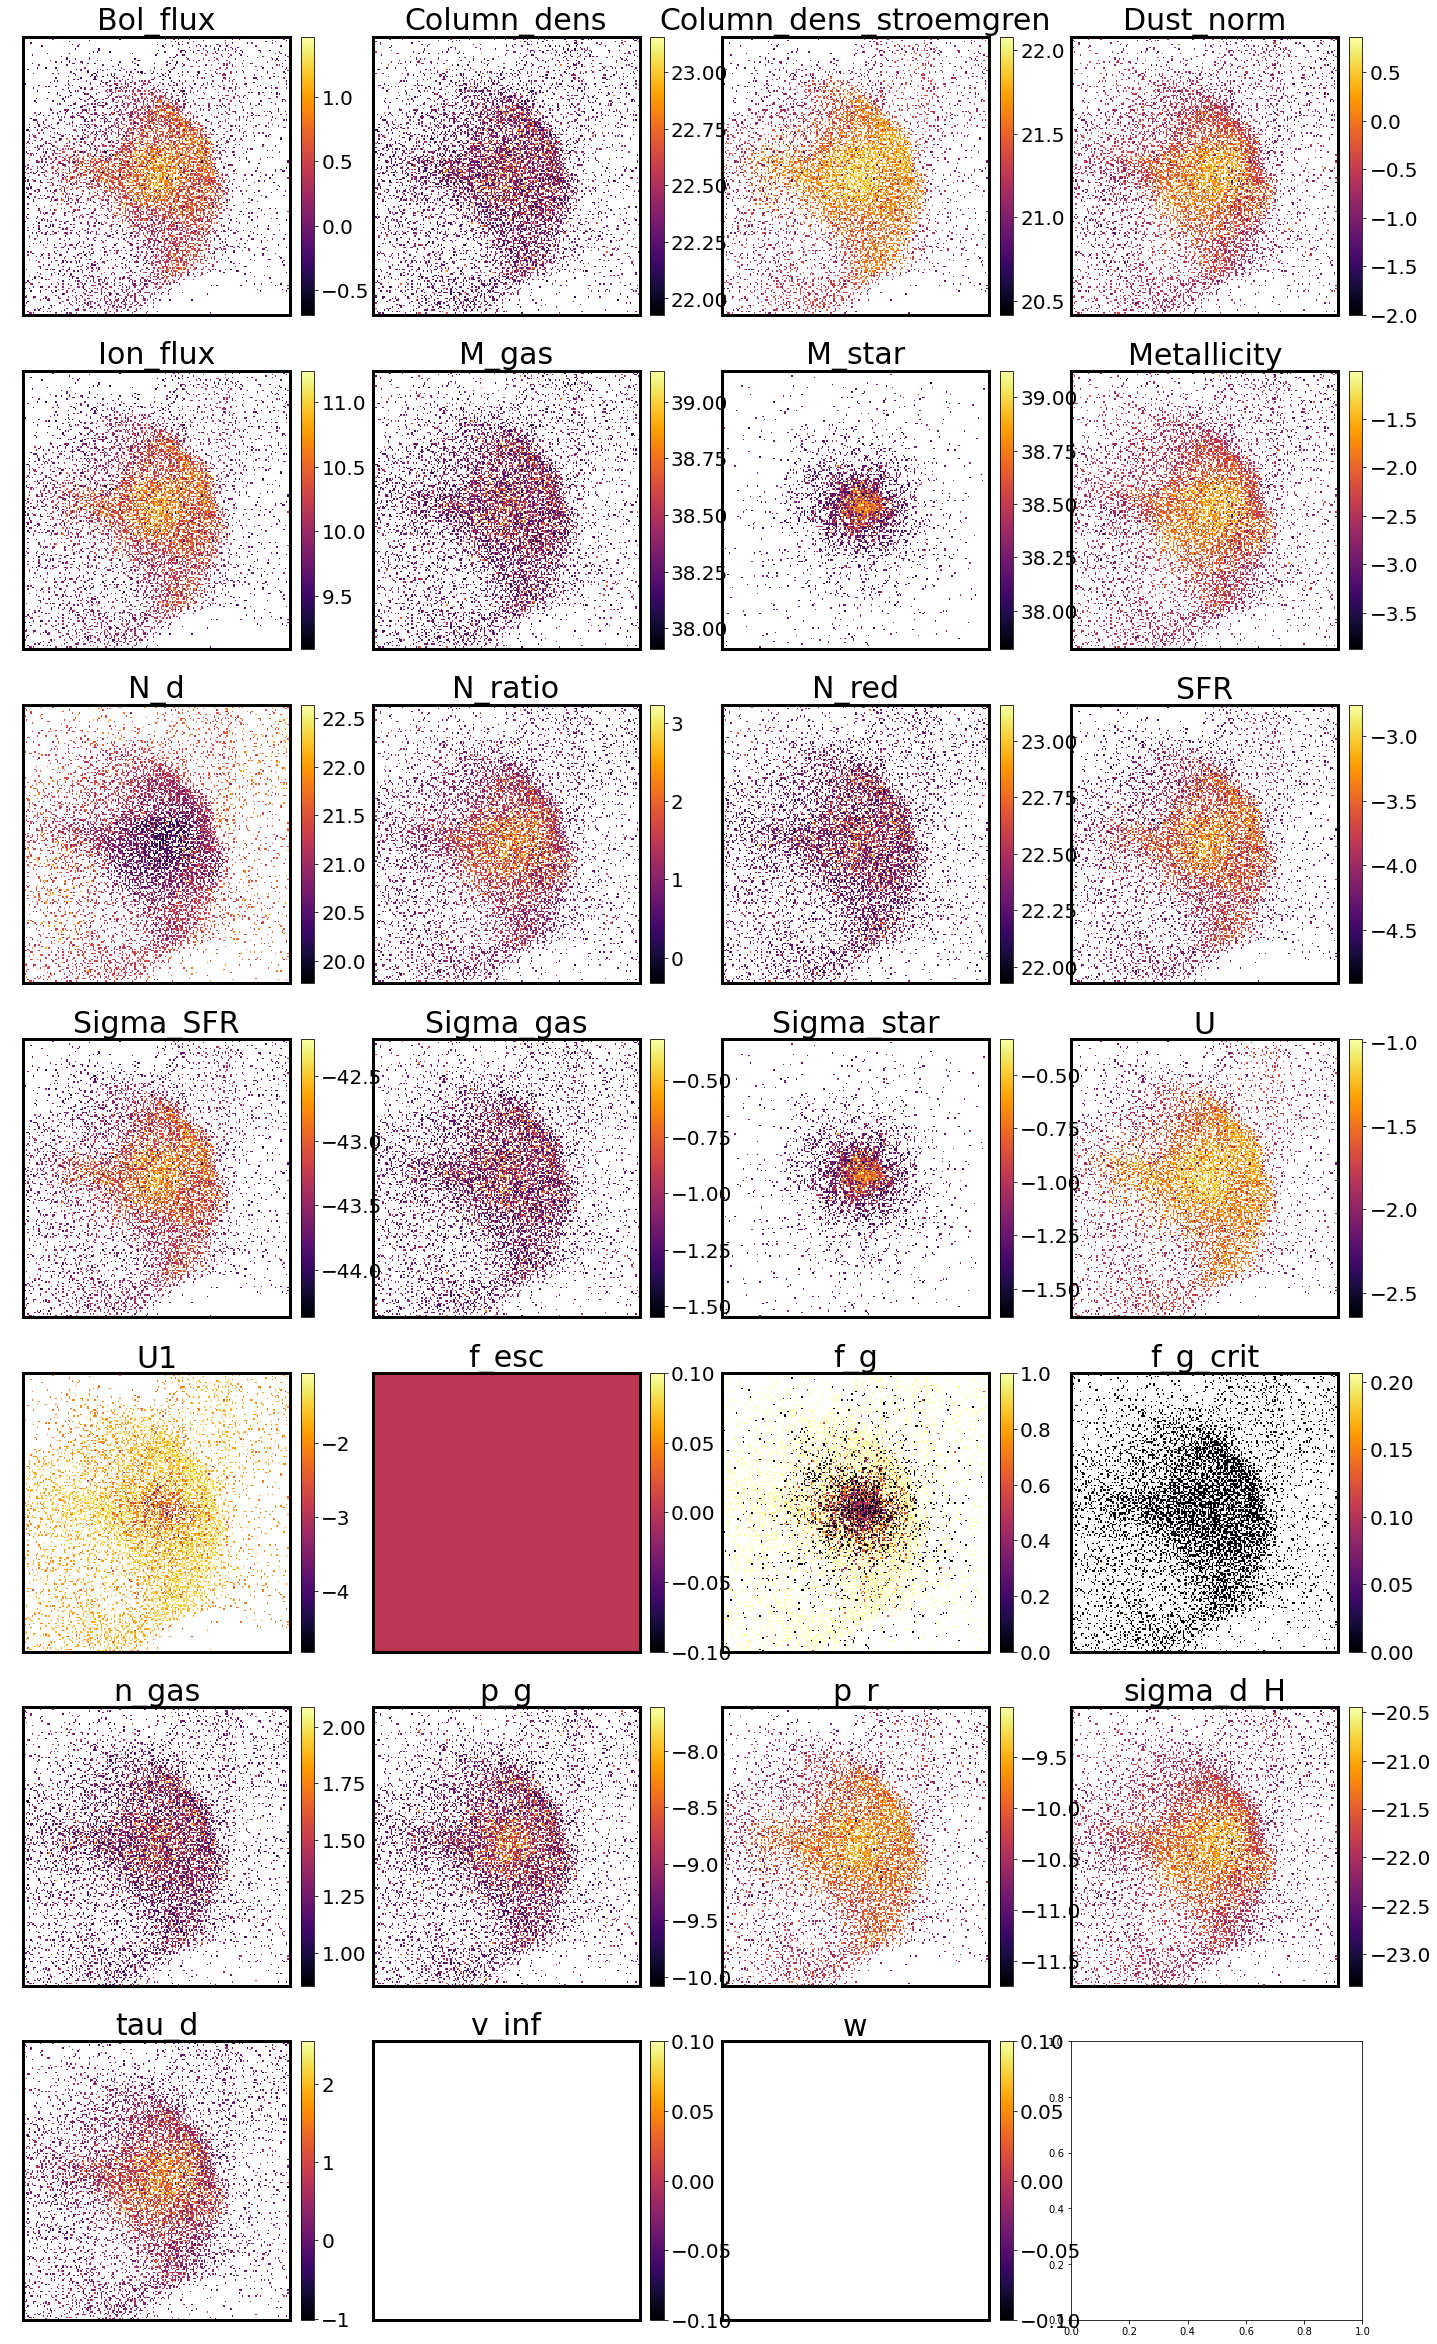

In [23]:
plot_multiple_histograms(maps)

In [24]:
weights = weights[:80]

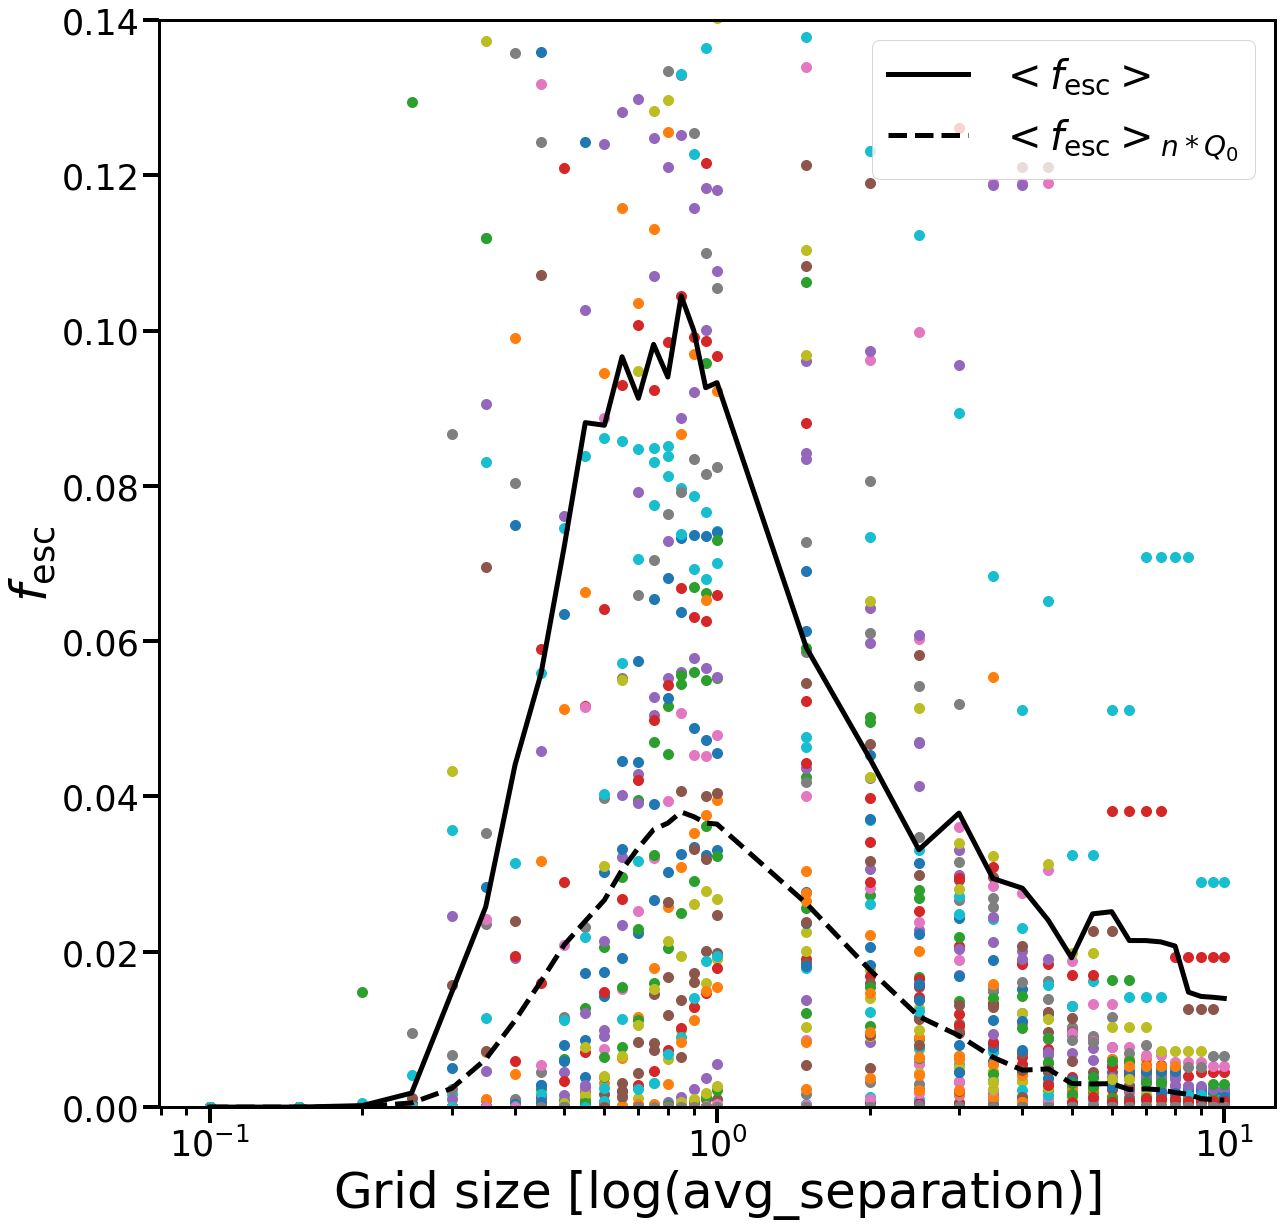

In [167]:
plot_convergence(test_df, 'f_esc', scales, scale_names, log=False, weights=weights[::-1])

In [147]:
x1 = np.arange(9.0).reshape((3, 3))

x2 = np.arange(3.0)

In [150]:
x1*x2

array([[ 0.,  1.,  4.],
       [ 0.,  4., 10.],
       [ 0.,  7., 16.]])

(82, 35)
(82,)
[[1.72660525e+08 8.68061790e+07 1.04574807e+08 ... 2.59707206e+02
  8.71227412e+02 4.10199810e+02]
 [1.72660525e+08 8.68061790e+07 1.04574807e+08 ... 2.59707206e+02
  8.71227412e+02 4.10199810e+02]
 [1.72660525e+08 8.68061790e+07 1.04574807e+08 ... 2.59707206e+02
  8.71227412e+02 4.10199810e+02]
 ...
 [1.72660525e+08 8.68061790e+07 1.04574807e+08 ... 2.59707206e+02
  8.71227412e+02 4.10199810e+02]
 [1.72660525e+08 8.68061790e+07 1.04574807e+08 ... 2.59707206e+02
  8.71227412e+02 4.10199810e+02]
 [1.72660525e+08 8.68061790e+07 1.04574807e+08 ... 2.59707206e+02
  8.71227412e+02 4.10199810e+02]]


ValueError: operands could not be broadcast together with shapes (82,35) (82,) 

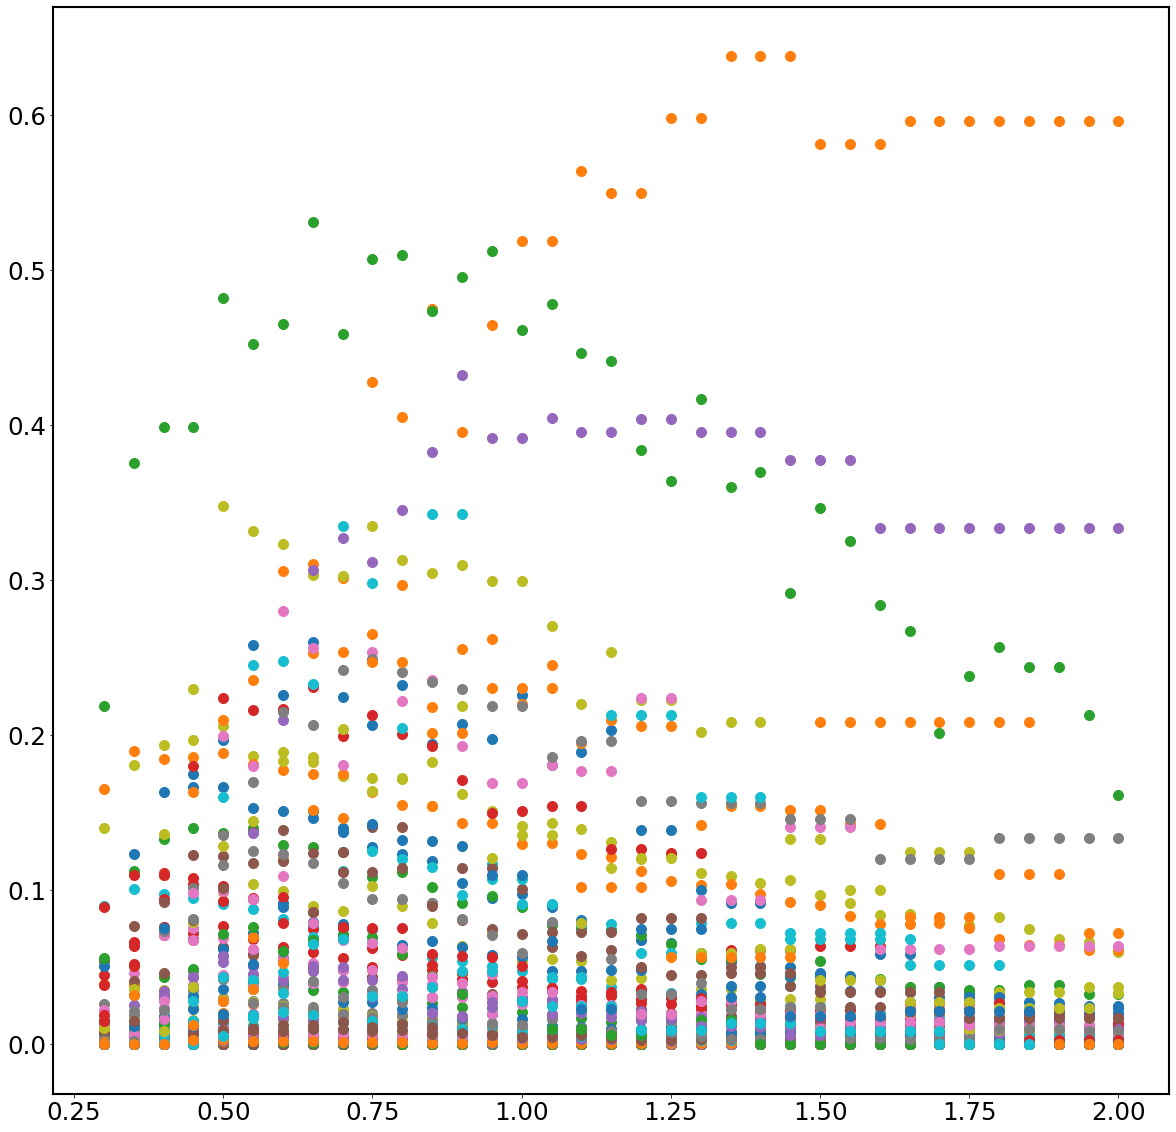

In [156]:
plot_convergence(test_df, 'f_esc', scales, scale_names, weights=weights)

In [110]:
f['0.005'].keys()

<KeysViewHDF5 ['12163', '23997', '241127', '249581', '2668', '3401', '35109', '369972', '5096', '90842']>

In [123]:
maps = f['3']['249581']

In [124]:
print(np.sum(np.array(maps['f_esc'])*np.array(maps['Ion_flux']))/np.sum(maps['Ion_flux']))

0.0


In [129]:
f.close()

In [128]:
test_df.index[0]

2668

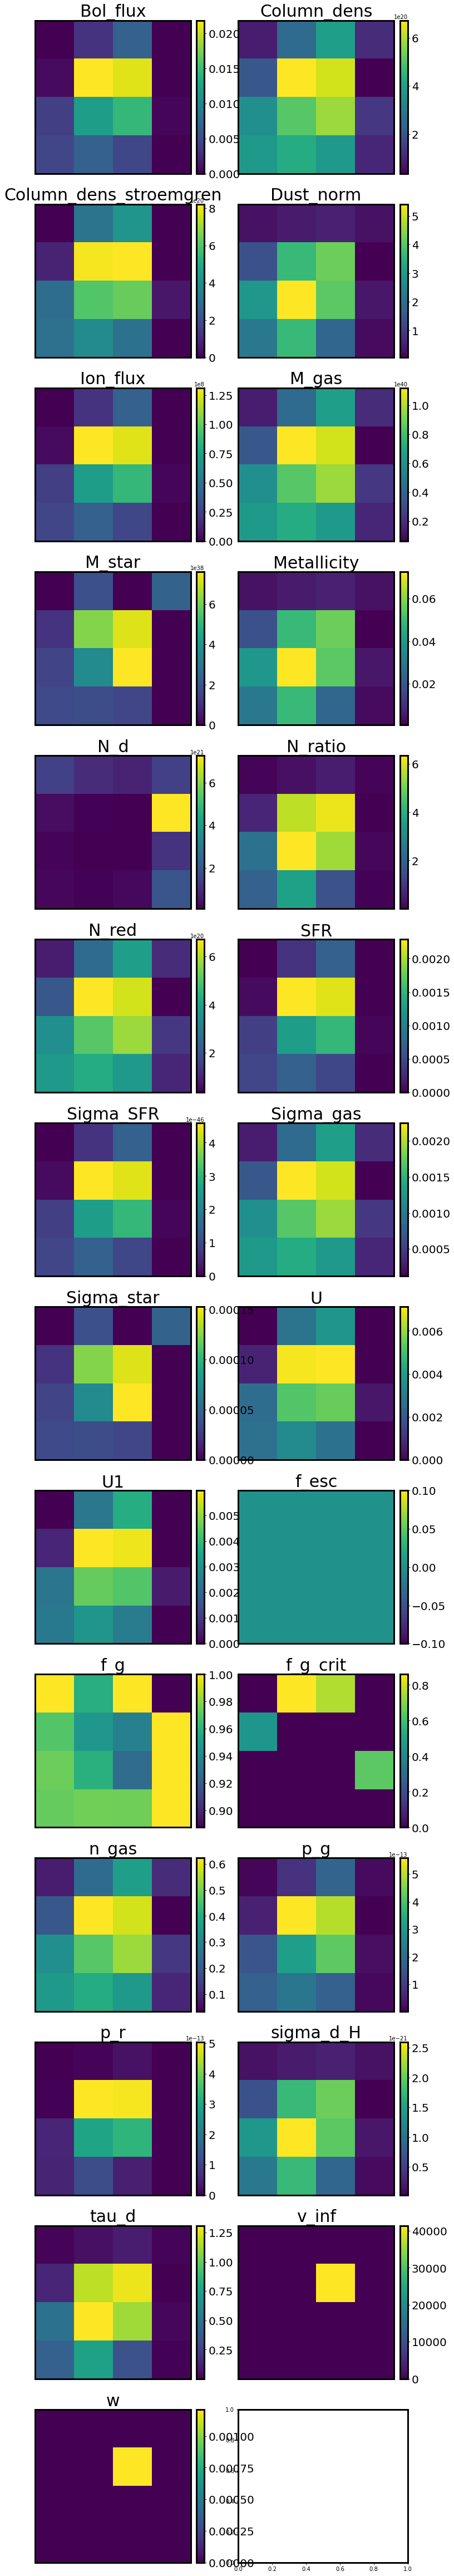

In [125]:
plot_multiple_histograms(maps)

In [21]:
f.close()